## Notebook 6: Van der Pol oscillator

This notebook illustrates the training and prediction of a Neural Ordinary Differential Equation (NODEs) model.  The data is fictitiously generated by solving the Van der Pol oscillator

$\frac{d^2 x}{dt^2}-\mu(1-x^2)\frac{d x}{dt}+x=0$

with initial condition $x(0)=2.0$ and $\frac{dx}{dt}(0)=0$.   In this notebook, we will use $\mu=1$. Training data is generated for $t\in[0,20]$. The intention is to try to use the NODEs model to predict the solution for $t\in[0,50]$.    As per convention, the second order equation will be expressed as a set of first order equations by letting

$u_1=x$ and

$u_2=\frac{dx}{dt}$

Thus the Van der Pol equation will look like

$\frac{du_1}{dt}=u_2$

$\frac{du_2}{dt}=(1-u_1^2)u_2-u_1$


The NODEs model look like


$\frac{d\vec{u}}{dt}=\vec{NN}(\vec{u};\vec{p})$


The Neural Network has two inputs, $u_1$ and $u_2$ and two outputs $du_1/dt$ and $du_2/dt$.  

In [22]:
using ComponentArrays
using Lux
using DiffEqFlux 
using OrdinaryDiffEq
using SciMLSensitivity
using Optimization
using OptimizationOptimisers
using Random
using CairoMakie
using MLUtils
using OrdinaryDiffEqTsit5

Parameters for Training Data

In [23]:
rng = Xoshiro(0) #random seed
u0 = Float32[2.0;0.0]
datasize = 300
tspan = (0.0f0, 20.0f0)
tsteps = range(tspan[1], tspan[2]; length = datasize)

EpanechnikovKernelBandwidth=0.02
noise=0.05

0.05

Parameters for Validation Data

In [24]:
tspan2 = (0.0f0, 50.0f0)
tsteps2 = range(tspan2[1], tspan2[2]; length = 500)

0.0f0:0.1002004f0:50.0f0

Training parameters

In [25]:
max_iter_colloc=5000
max_iter_NODEs=5000
learning_rate=0.01

0.01

Van der Pol equation


$\frac{du_1}{dt}=u_2$

$\frac{du_2}{dt}=(1-u_1^2)u_2-u_1$

In [26]:
function trueODEfunc(du, u, p, t)
    du[1]=u[2]
    du[2]=(1-u[1]*u[1])*u[2]-u[1]
end

trueODEfunc (generic function with 1 method)

Generating training data

In [27]:
prob_trueode = ODEProblem(trueODEfunc, u0, tspan)
data = Array(solve(prob_trueode, Tsit5(); saveat = tsteps)) .+ noise*randn(length(u0), datasize)

2×300 Matrix{Float64}:
 2.04505     2.07354    2.07447   …  1.97833   2.02374    2.02534
 0.0668935  -0.105806  -0.253069     0.267751  0.184436  -0.0427217

Generating Validation data

In [28]:
prob_trueode_sol = ODEProblem(trueODEfunc, u0, tspan2)
data_true = Array(solve(prob_trueode_sol, Tsit5(); saveat = tsteps2)) 

2×500 Matrix{Float32}:
 2.0   1.9909     1.96683    1.93159   …  -1.96639   -1.99949   -2.00668
 0.0  -0.172951  -0.301163  -0.397904     -0.484746  -0.188734   0.0338534

Plot to see how the training and validation data looks like

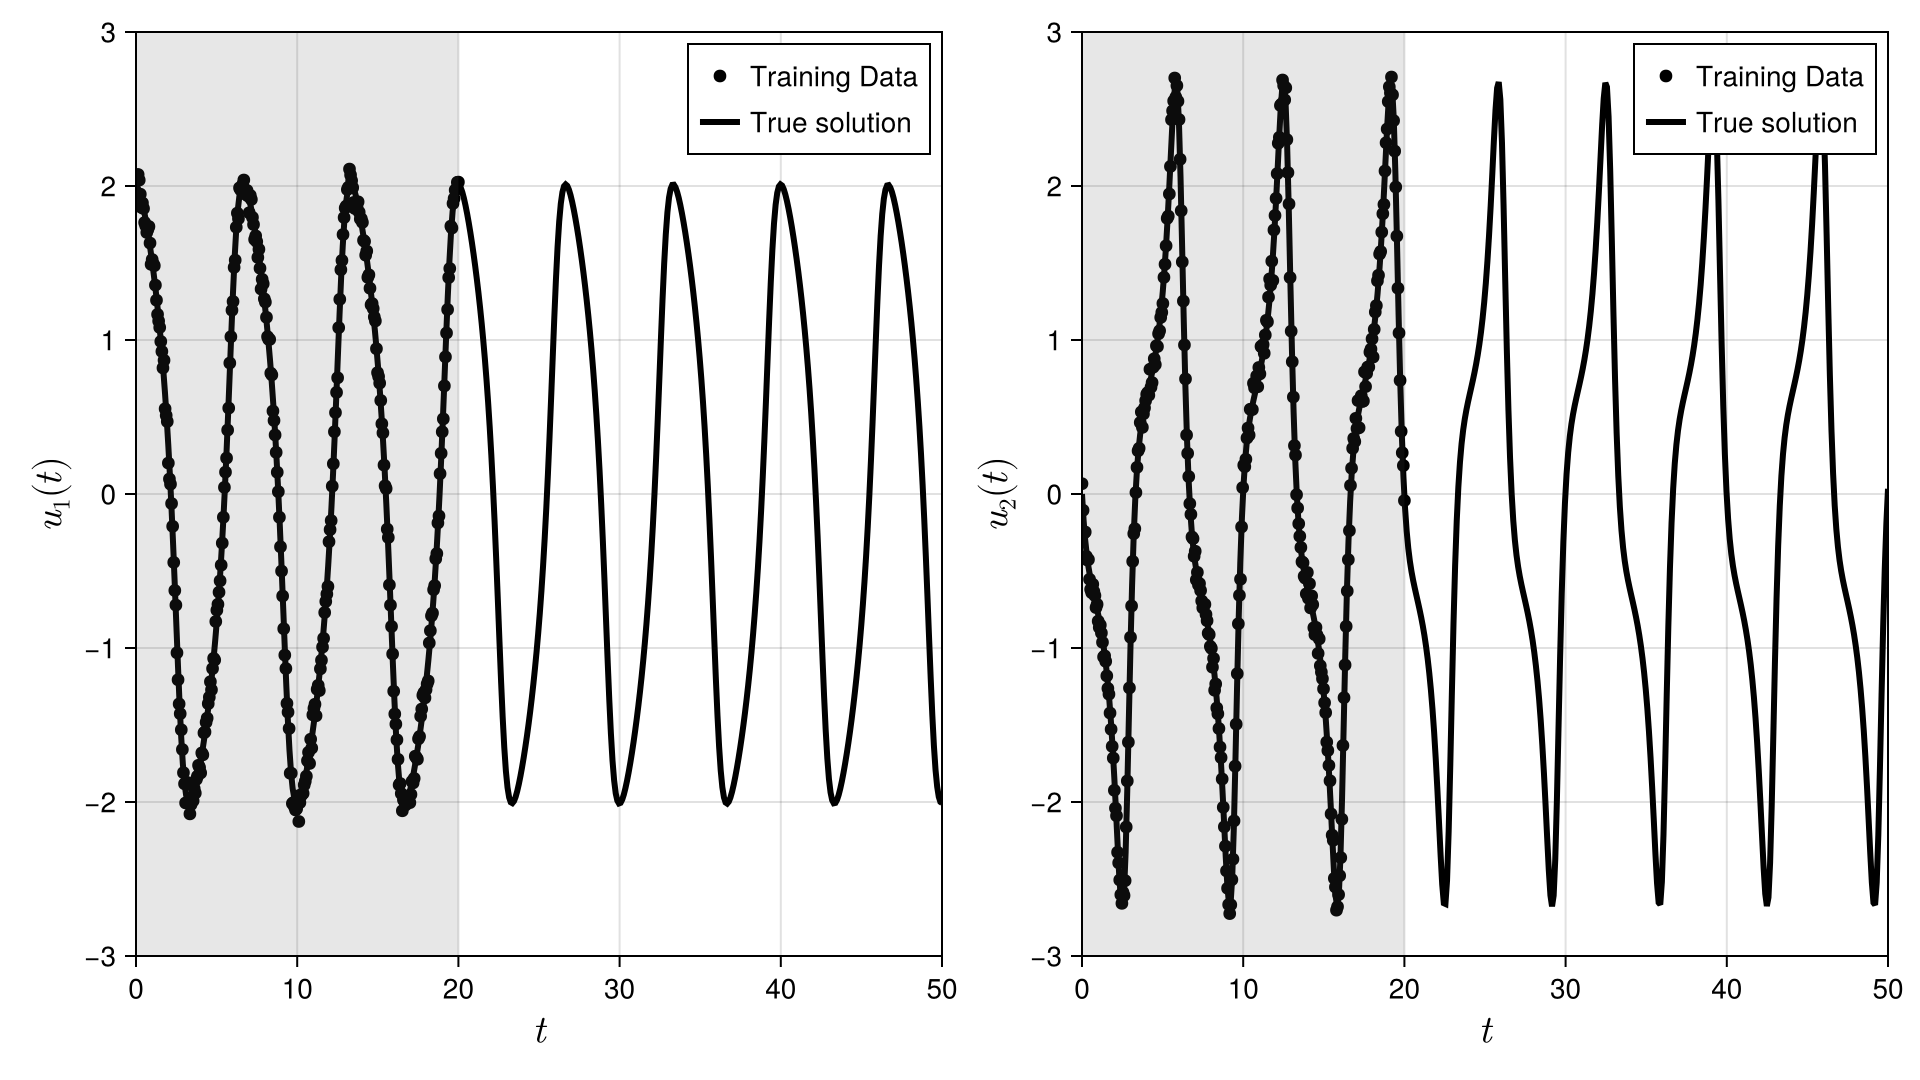

In [29]:
fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_1(t)",title="")
CairoMakie.scatter!(ax1,tsteps, data[1,:];color=:black,label="Training Data")
CairoMakie.lines!(ax1,tsteps2, data_true[1,:]; linewidth = 3,color=:black,label="True solution")
CairoMakie.vspan!(ax1,tspan[1], tspan[2];color=(:grey, 0.1))
axislegend(ax1;position=:rt)
xlims!(ax1,tspan2[1],tspan2[2])
ylims!(ax1,-3,3)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_2(t)",title="")
CairoMakie.scatter!(ax2,tsteps, data[2,:];color=:black,label="Training Data")
CairoMakie.lines!(ax2,tsteps2, data_true[2,:]; linewidth = 3,color=:black,label="True solution")
CairoMakie.vspan!(ax2,tspan[1], tspan[2];color=(:grey, 0.1))
axislegend(ax2;position=:rt)
xlims!(ax2,tspan2[1],tspan2[2])
ylims!(ax2,-3,3)
#save("figures/06VanDerPolTrainingData.png", fig)
fig

Using the inbuilt `collocate_data()` function to smooth the data and approximate the time derivative of the data

In [30]:
du, u = collocate_data(data, tsteps, EpanechnikovKernel(),EpanechnikovKernelBandwidth)

([0.7222570558121735 -0.025739506915455124 … 0.14627328963048658 0.16602966143457998; -2.448274616220271 -2.0315702040933328 … -2.050878268432854 -1.420086172084098], [2.088383857463914 2.062298833160011 … 2.0154245625560563 2.0374780329074875; 0.021065593686197738 -0.08846225944481628 … 0.12033516710017918 -0.06013552317489977])

Plot the smoothed data to check if it looks reasonable

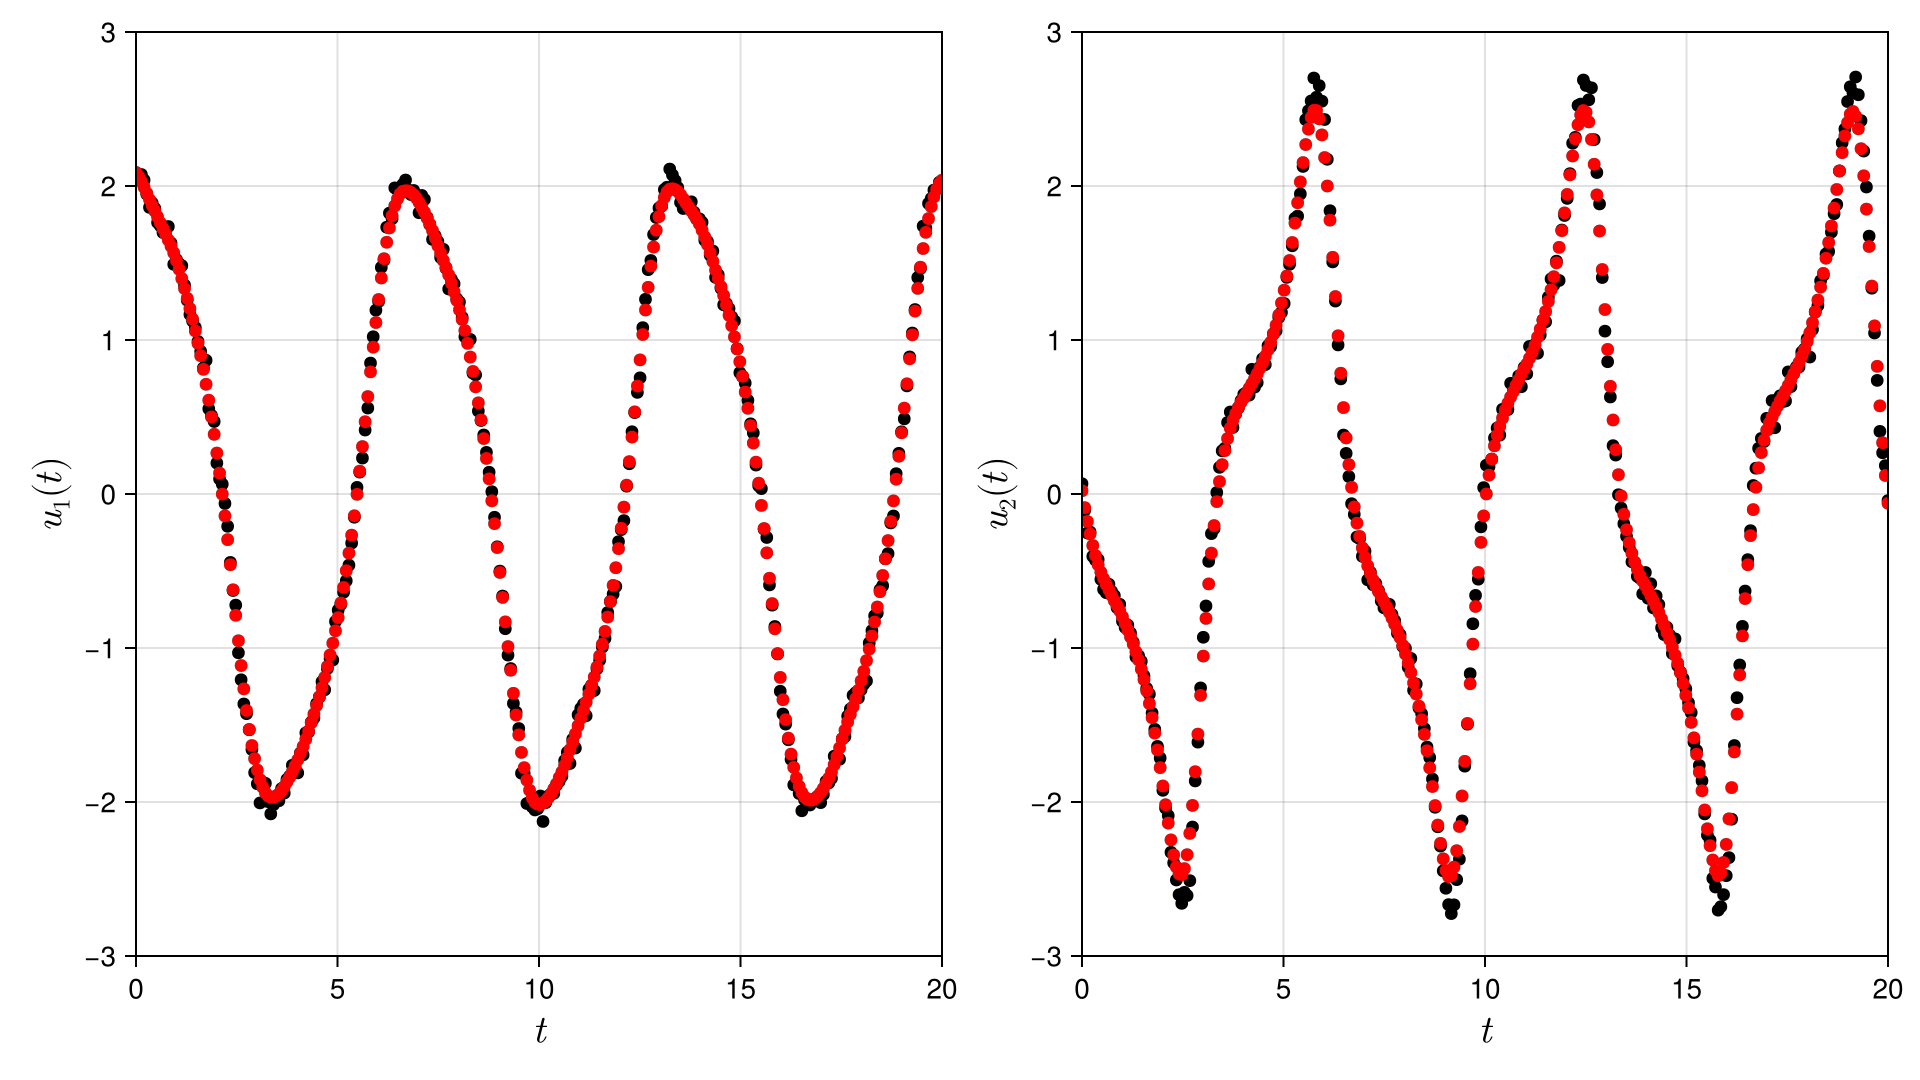

In [31]:
fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_1(t)")
CairoMakie.scatter!(ax1,tsteps, data[1,:];color=:black)
CairoMakie.scatter!(ax1,tsteps, u[1,:];color=:red)
xlims!(ax1,0,20)
ylims!(ax1,-3,3)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_2(t)")
CairoMakie.scatter!(ax2,tsteps, data[2,:];color=:black)
CairoMakie.scatter!(ax2,tsteps, u[2,:]; color=:red)
xlims!(ax2,0,20)
ylims!(ax2,-3,3)
save("colloc.png", fig)
fig

Plot the approximated derivative of the data to check if it looks reasonable

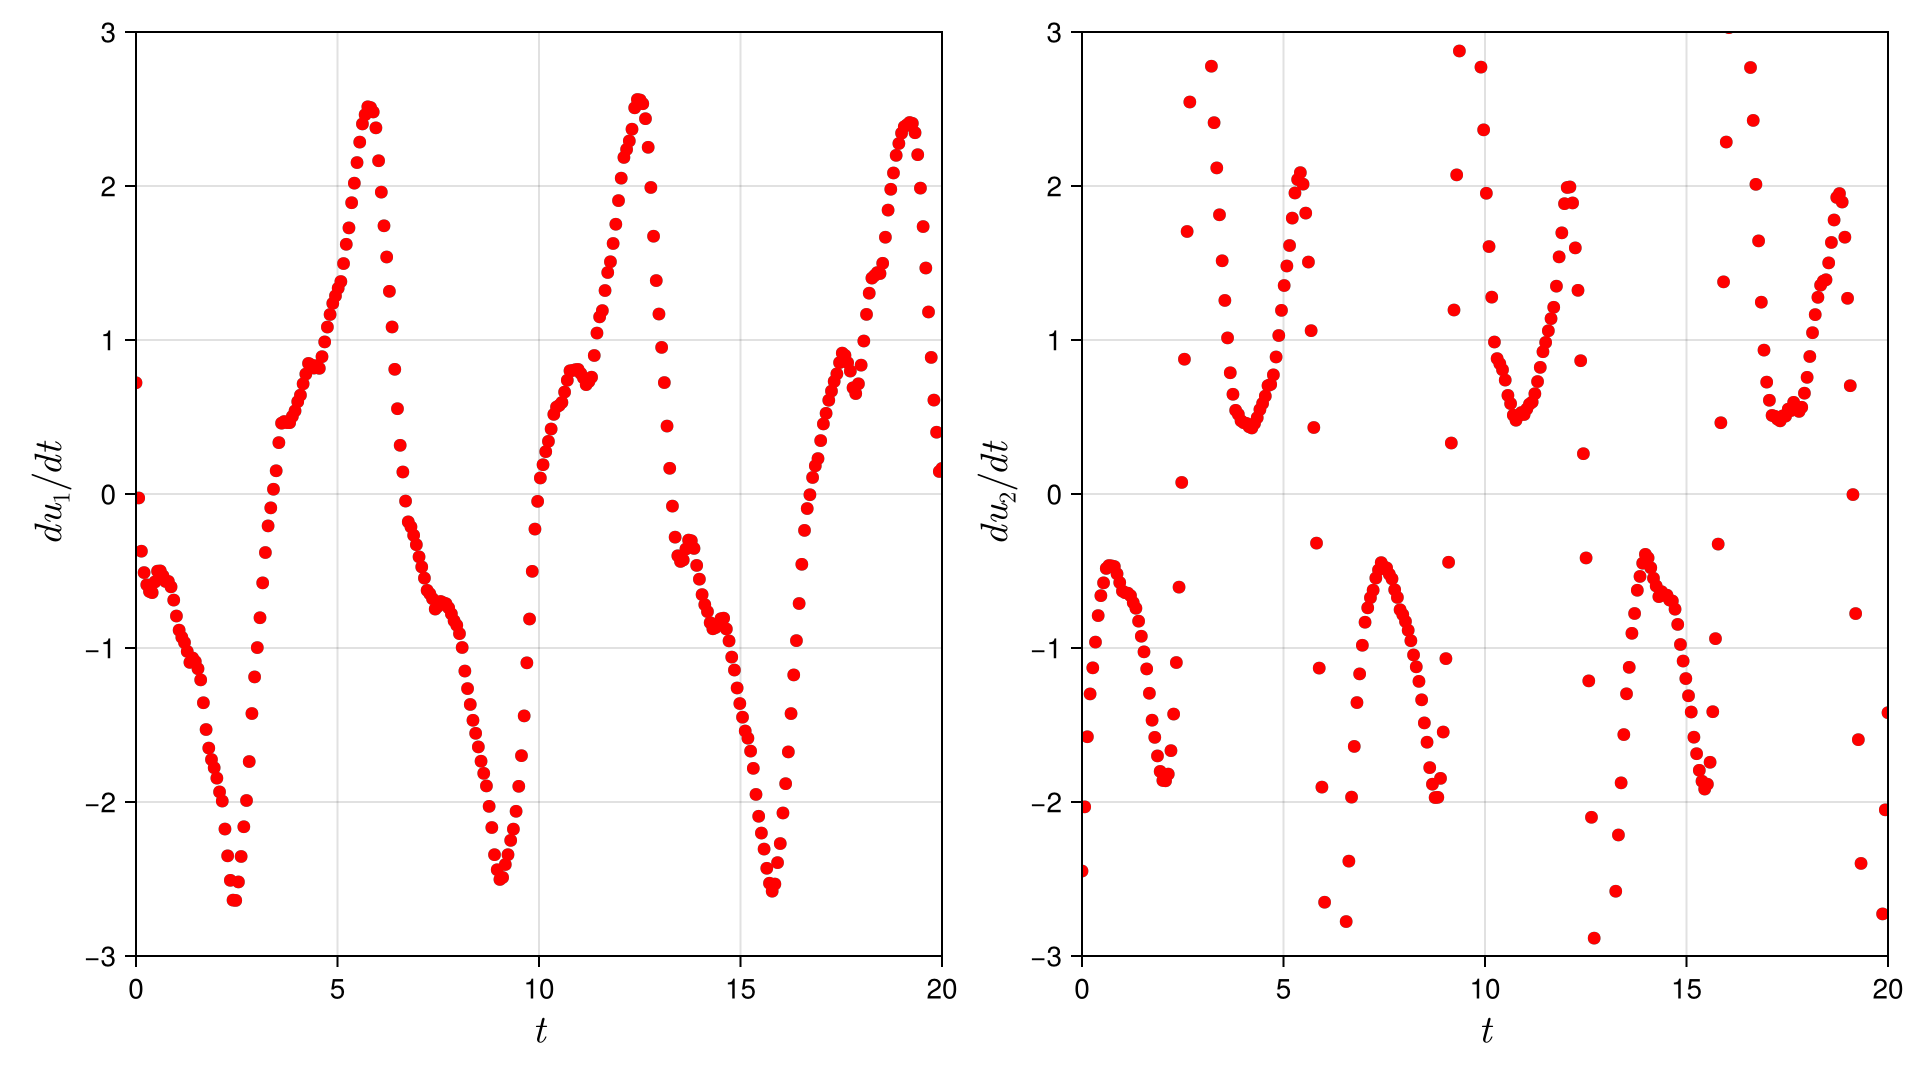

In [32]:
fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)

ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"du_1/dt")
xlims!(ax1,0,20)
ylims!(ax1,-3,3)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"du_2/dt")
xlims!(ax2,0,20)
ylims!(ax2,-3,3)

CairoMakie.scatter!(ax1,tsteps, du[1,:];color=:red)
CairoMakie.scatter!(ax2,tsteps, du[2,:];color=:red)
fig

Set up architecture of Neural Network

In [33]:
dudtNODEs = Chain(Dense(2, 5, tanh),
            Dense(5, 5, tanh),
             Dense(5, 2))
pinit, st = Lux.setup(rng, dudtNODEs)

((layer_1 = (weight = Float32[-0.058096703 1.4784337; -0.38498044 -0.936009; … ; -1.7614043 -0.7860806; -1.2246865 0.65978104], bias = Float32[-0.2306831, -0.5425951, 0.5163813, -0.5524123, -0.119110115]), layer_2 = (weight = Float32[-1.0147992 -0.16287804 … -0.14458258 1.1619588; -0.2060021 1.0493203 … 1.0649743 1.2428114; … ; 0.5692708 0.51255274 … -1.1117479 -0.27292225; 0.26297426 -0.91578704 … 0.86948603 -0.70678467], bias = Float32[-0.29378006, 0.11851501, 0.11447332, -0.40796348, -0.16753744]), layer_3 = (weight = Float32[-0.49382704 -0.19511192 … 0.1928618 -0.26110658; -0.0077854805 0.5515388 … 0.28800184 0.20672485], bias = Float32[-0.28049797, -0.25374046])), (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()))

In [34]:
function loss(p,(du, u))
    cost = zero(first(p))
    for i in 1:size(du, 2)
        _du, _ = dudtNODEs(@view(u[:, i]), p, st)
        dui = @view du[:, i]
        cost += sum(abs2, _du  .- dui)
    end
    return 0.5*cost/size(du, 2)
end

loss (generic function with 1 method)

Collocation training

In [35]:
# Initialize a vector to store loss values
loss_history = Float64[]

callback = function (p, l)
    if p.iter % 100 == 0
        println("Iteration: $(p.iter), Loss: $l")
    end
    push!(loss_history, l)
    return false
end

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction((p, x) -> loss(p,(du,u)), adtype)
optprob = Optimization.OptimizationProblem(optf, ComponentArray(pinit),(du,u))
result_neuralode = Optimization.solve(optprob, OptimizationOptimisers.Adam(learning_rate); callback, epochs =max_iter_colloc)


Iteration: 100, Loss: 0.3097609255006354
Iteration: 200, Loss: 0.03100950833076057
Iteration: 300, Loss: 0.01587405128127316
Iteration: 400, Loss: 0.013459609348670541
Iteration: 500, Loss: 0.01243245444183874
Iteration: 600, Loss: 0.01179621791051077
Iteration: 700, Loss: 0.01135248695126227
Iteration: 800, Loss: 0.011006319509170122
Iteration: 900, Loss: 0.010717997370355026
Iteration: 1000, Loss: 0.01047044678964875
Iteration: 1100, Loss: 0.010253767918866187
Iteration: 1200, Loss: 0.010058443987109434
Iteration: 1300, Loss: 0.009870126241796461
Iteration: 1400, Loss: 0.009669427704766864
Iteration: 1500, Loss: 0.009460098204630013
Iteration: 1600, Loss: 0.009269564597006976
Iteration: 1700, Loss: 0.009108199486981737
Iteration: 1800, Loss: 0.008972332873620356
Iteration: 1900, Loss: 0.008855826200272475
Iteration: 2000, Loss: 0.008754155578552863
Iteration: 2100, Loss: 0.008664605020789263
Iteration: 2200, Loss: 0.008585381196298486
Iteration: 2300, Loss: 0.008514918570224498
Itera

retcode: Default
u: ComponentVector{Float32}(layer_1 = (weight = Float32[-0.5260791 0.89458627; -0.17697446 -0.98663086; … ; -1.8950075 0.4700005; -1.0812645 0.87504315], bias = Float32[-0.7494276, -0.7047728, 0.8099948, -0.2664647, -0.09737396]), layer_2 = (weight = Float32[-1.7535825 -0.11124096 … -0.48362544 0.5520923; -1.383759 1.8954659 … 0.64266837 2.6381981; … ; 1.092361 -1.1664156 … -1.9049937 0.19663347; 0.38813376 -0.984172 … 1.0363456 0.6389848], bias = Float32[-1.4247228, -0.36892137, -0.2740955, 0.087768085, 0.85795164]), layer_3 = (weight = Float32[-0.97805846 0.19853918 … 1.2197692 -0.22327846; 1.2016329 1.8086505 … 0.3827441 2.0859396], bias = Float32[0.02421969, -0.0016562433]))

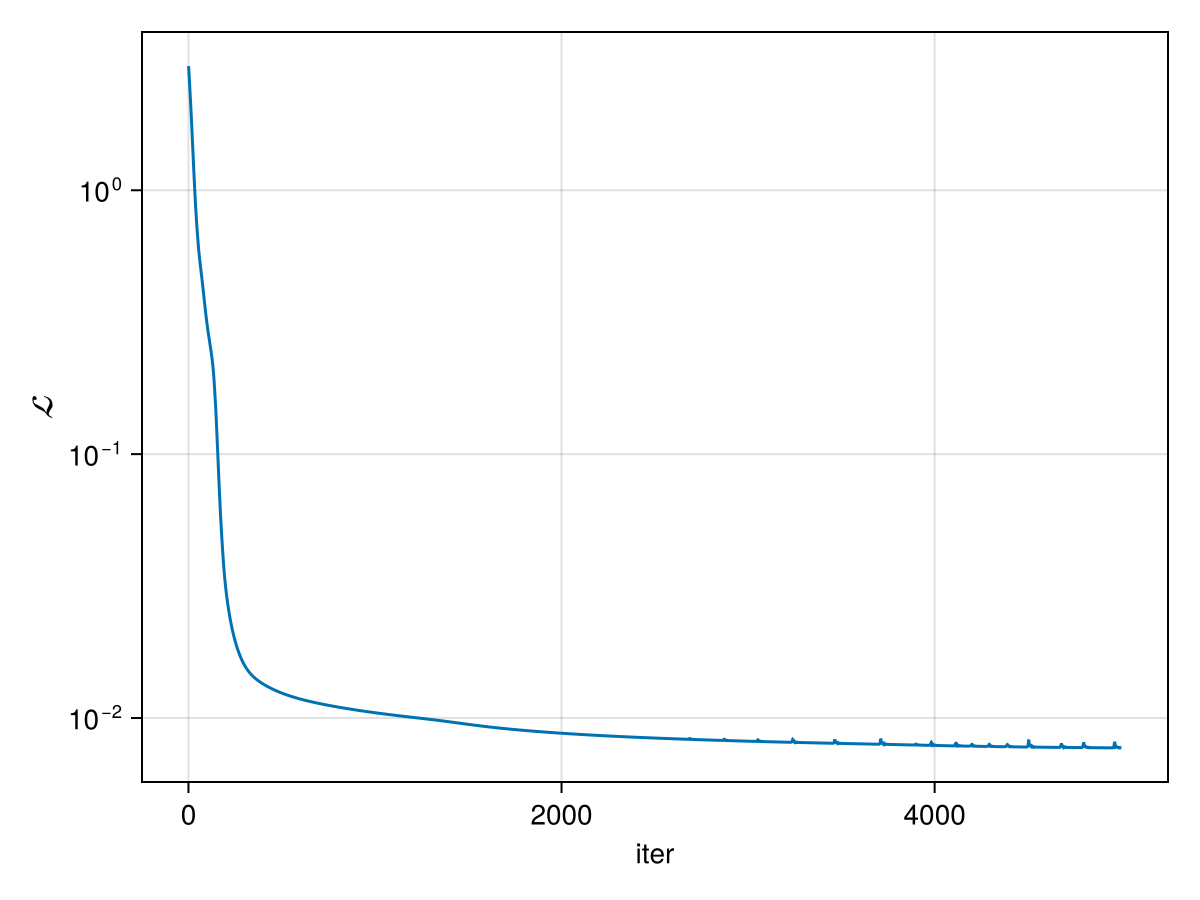

In [36]:
#Plot loss function
#
loss_history_collocation=copy(loss_history)
fig = CairoMakie.Figure()
ax = CairoMakie.Axis(fig[1, 1],yscale=log10,xlabel="iter",ylabel=L"\mathcal{L}")
CairoMakie.lines!(ax,loss_history_collocation)
save("loss_collocation.png", fig)
fig


Have a look at results of the collocation prediction

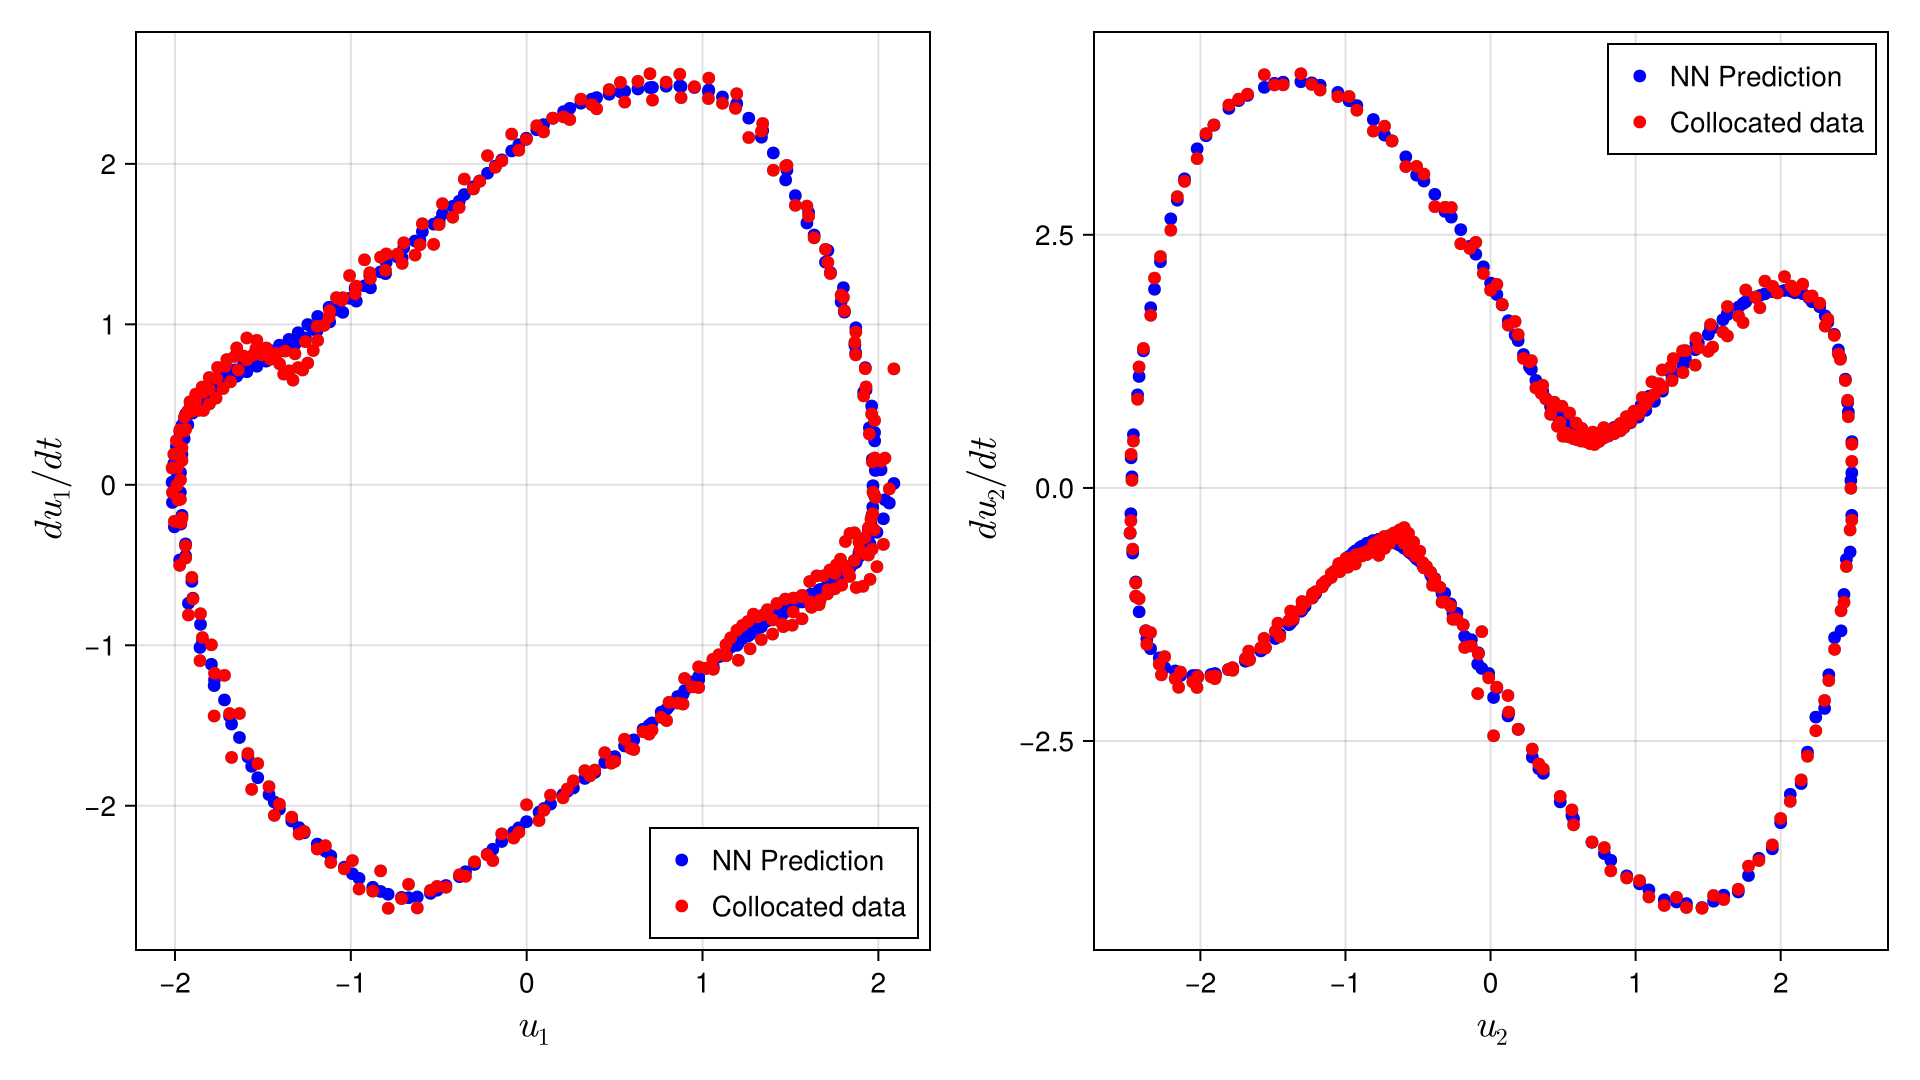

In [37]:
du_pred,_=dudtNODEs(u, result_neuralode.u, st)
fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"u_1",
    ylabel=L"du_1/dt")
CairoMakie.scatter!(ax1,u[1,:],du_pred[1,:],marker=:circle,color=:blue,label="NN Prediction")
CairoMakie.scatter!(ax1,u[1,:],du[1,:],marker=:circle,color=:red, label="Collocated data")
axislegend(ax1;position=:rb)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"u_2",
    ylabel=L"du_2/dt")
CairoMakie.scatter!(ax2,u[2,:],du_pred[2,:],marker=:circle,color=:blue,label="NN Prediction")
CairoMakie.scatter!(ax2,u[2,:],du[2,:],marker=:circle,color=:red, label="Collocated data")
axislegend(ax2;position=:rt)

fig


Predict using model for collocation training and compare with validation data

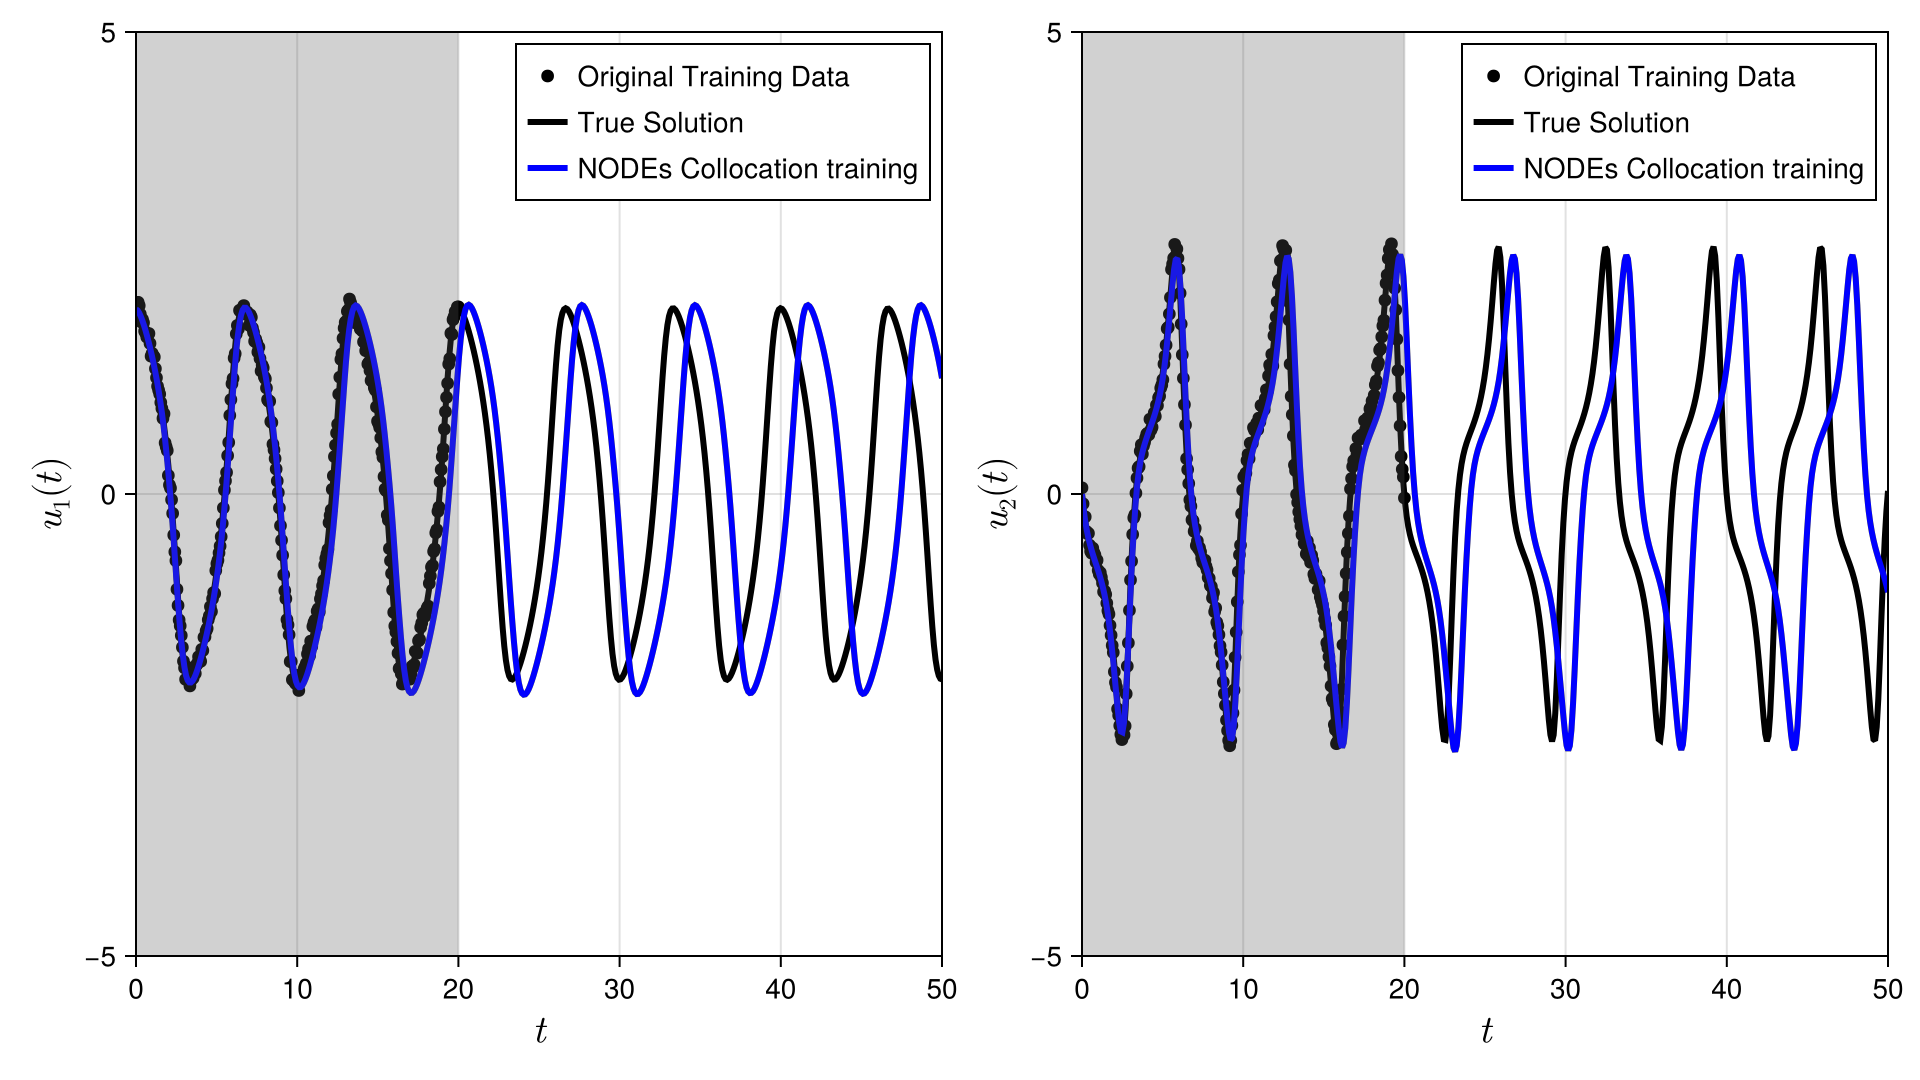

In [38]:
smodel_colloc = StatefulLuxLayer(dudtNODEs, result_neuralode, st)
dudt_colloc(u, p, t) = smodel_colloc(u, p)
prob_colloc = ODEProblem(dudt_colloc, u0, (tspan2[1], tspan2[2]),result_neuralode.u)
nn_sol_colloc = solve(prob_colloc, Tsit5();  saveat=tsteps2)
ComputedSolutionColloc=convert(AbstractArray,nn_sol_colloc)

fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_1(t)")

CairoMakie.scatter!(ax1,tsteps, data[1,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax1,tsteps2, data_true[1,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax1,nn_sol_colloc.t,ComputedSolutionColloc[1,:]; linewidth = 3,color=:blue,label="NODEs Collocation training")
CairoMakie.vspan!(ax1,tspan[1], tspan[2];color=(:grey, 0.2))
axislegend(ax1;position=:rt)
xlims!(ax1,tspan2[1],tspan2[2])
ylims!(ax1,-5,5)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_2(t)")
CairoMakie.scatter!(ax2,tsteps, data[2,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax2,tsteps2, data_true[2,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax2,nn_sol_colloc.t,ComputedSolutionColloc[2,:]; linewidth = 3,color=:blue,label="NODEs Collocation training")
CairoMakie.vspan!(ax2,tspan[1], tspan[2];color=(:grey, 0.2))
axislegend(ax2;position=:rt)
xlims!(ax2,tspan2[1],tspan2[2])
ylims!(ax2,-5,5)
#save("figures/06VanDerPolResultColloc.png", fig)
fig

Now do NODEs trainingm using the adjoint method

In [39]:
smodel = StatefulLuxLayer(dudtNODEs, result_neuralode, st)

function loss_adjoint(θ, (u, t))
    u0 = u[:, 1]
    dudt(u, p, t) = smodel(u, p)
    prob = ODEProblem(dudt, u0, (t[1], t[end]), θ)
    sol = solve(prob, Tsit5(); saveat=t)
    pred = stack(sol.u)

    return MSELoss()(pred, u)
end

loss_history = Float64[]
opt_func = OptimizationFunction(loss_adjoint, Optimization.AutoZygote())
opt_prob = OptimizationProblem(opt_func, result_neuralode.u, (data,tsteps))
numerical_neuralode = Optimization.solve(opt_prob, Optimisers.Adam(learning_rate); callback, epochs = max_iter_NODEs)
loss_history_NODEs=copy(loss_history)


Iteration: 100, Loss: 1.8905808760847425
Iteration: 200, Loss: 1.417836011971982
Iteration: 300, Loss: 1.2807661049836983
Iteration: 400, Loss: 0.06409511061384493
Iteration: 500, Loss: 0.06576627003916409
Iteration: 600, Loss: 0.030058953058409735
Iteration: 700, Loss: 0.02379276062128834
Iteration: 800, Loss: 0.025751655577313327
Iteration: 900, Loss: 0.034033716168945946
Iteration: 1000, Loss: 0.021778237121808004
Iteration: 1100, Loss: 0.013298658173565523
Iteration: 1200, Loss: 0.040213508681548
Iteration: 1300, Loss: 0.02360850341852806
Iteration: 1400, Loss: 0.020529811415339237
Iteration: 1500, Loss: 0.016840047962281578
Iteration: 1600, Loss: 0.057979557662184954
Iteration: 1700, Loss: 0.022601505212204963
Iteration: 1800, Loss: 0.01798009803459467
Iteration: 1900, Loss: 0.016169079473217992
Iteration: 2000, Loss: 0.013411736026343194
Iteration: 2100, Loss: 0.013041065540155175
Iteration: 2200, Loss: 0.18455741860323965
Iteration: 2300, Loss: 0.013301953463550025
Iteration: 24

5001-element Vector{Float64}:
 0.9142392846026796
 1.9791748232243258
 2.102592589459063
 2.1364428845640644
 2.1515553577604307
 2.159083159990574
 2.1624549562981157
 2.163062322954802
 2.161651038087453
 2.1587211619985434
 ⋮
 0.011710296726280003
 0.00865576251697325
 0.015116183163015303
 0.009868154634691501
 0.01376492347714493
 0.009132357682698537
 0.016231158933035443
 0.01525183842471715
 0.0076856735550292635

Predict using NODEs solution and plot

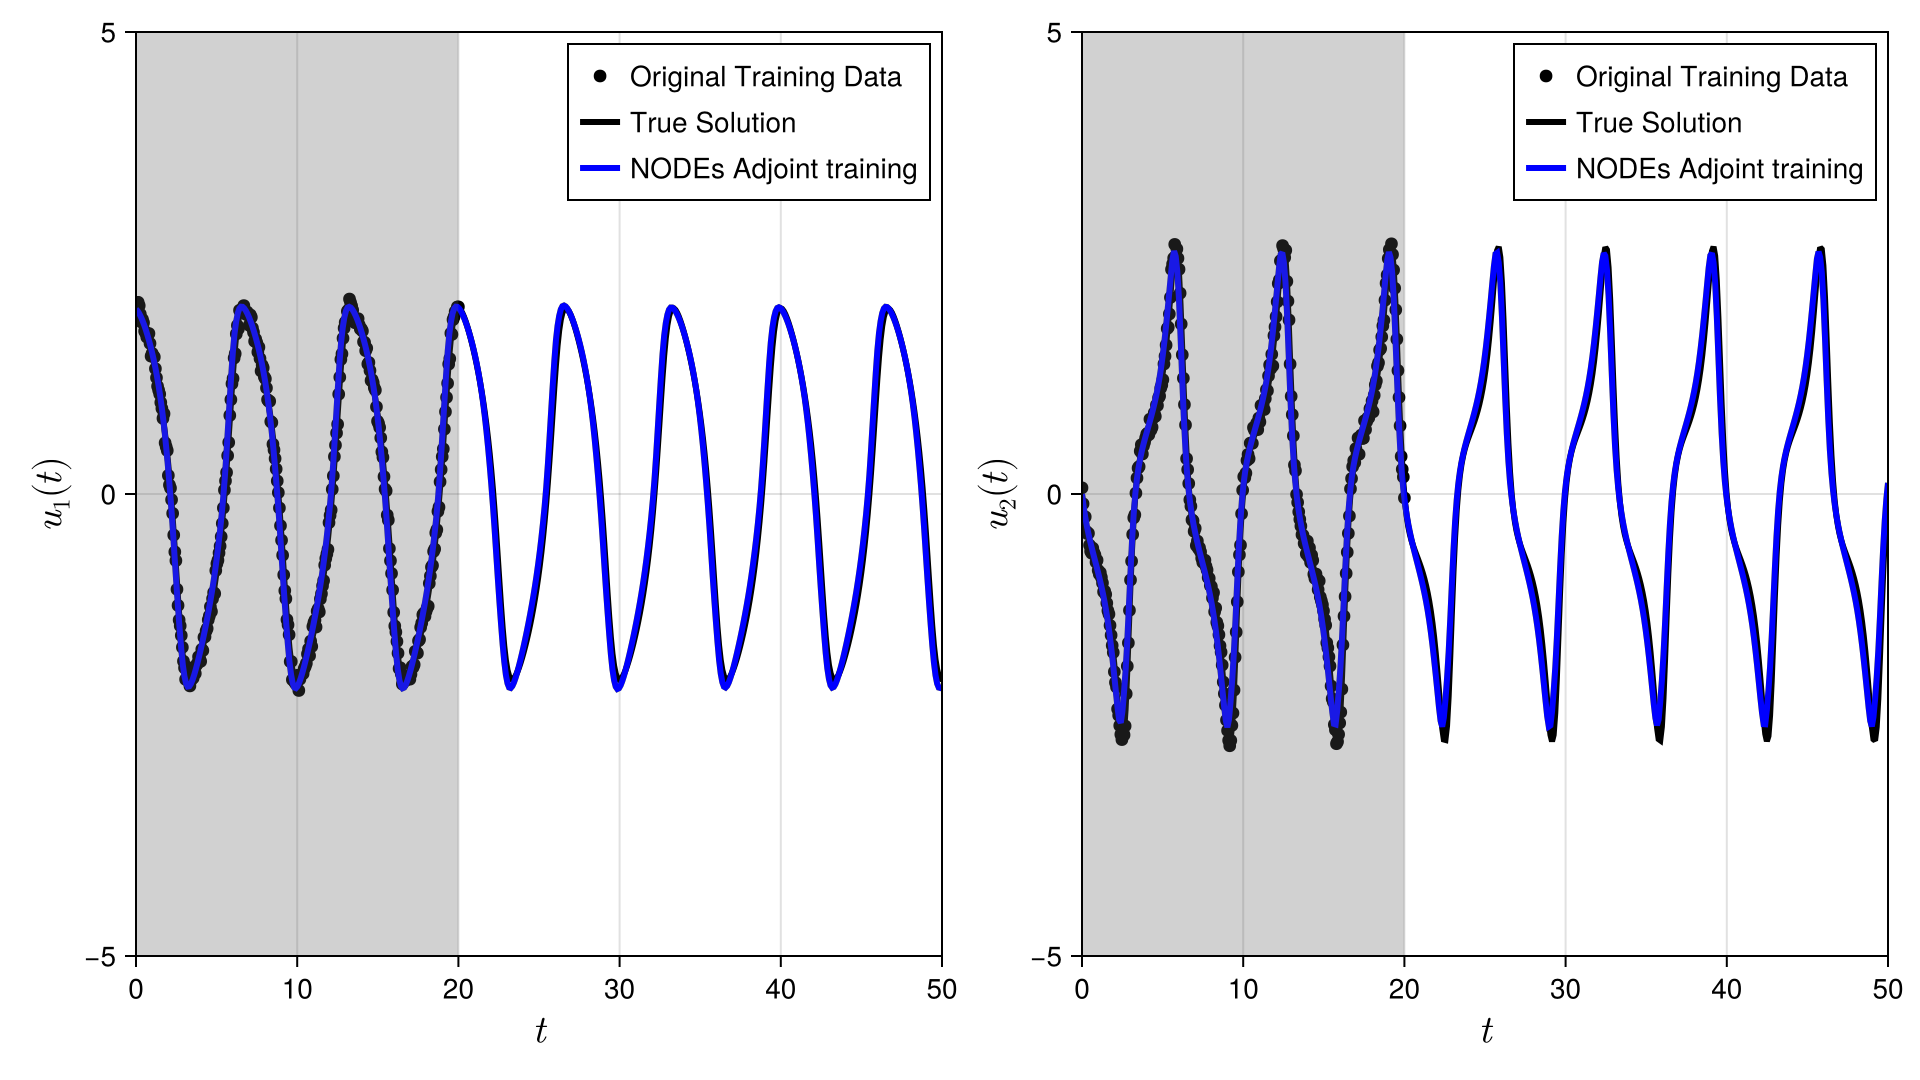

In [40]:
trained_model=StatefulLuxLayer(dudtNODEs, numerical_neuralode.u, smodel.st)
Finaldudt(u, p, tplot) = trained_model(u, p)
prob = ODEProblem(Finaldudt, u0, (tspan2[1],tspan2[2]), numerical_neuralode.u) 
nn_sol = solve(prob, Tsit5(); saveat=tsteps2)


ComputedSolution_nodes=convert(AbstractArray,nn_sol)


fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_1(t)")

CairoMakie.scatter!(ax1,tsteps, data[1,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax1,tsteps2, data_true[1,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax1,nn_sol_colloc.t,ComputedSolution_nodes[1,:]; linewidth = 3,color=:blue,label="NODEs Adjoint training")
CairoMakie.vspan!(ax1,tspan[1], tspan[2];color=(:grey, 0.2))
axislegend(ax1;position=:rt)
xlims!(ax1,tspan2[1],tspan2[2])
ylims!(ax1,-5,5)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_2(t)")
CairoMakie.scatter!(ax2,tsteps, data[2,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax2,tsteps2, data_true[2,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax2,nn_sol_colloc.t,ComputedSolution_nodes[2,:]; linewidth = 3,color=:blue,label="NODEs Adjoint training")
CairoMakie.vspan!(ax2,tspan[1], tspan[2];color=(:grey, 0.2))
axislegend(ax2;position=:rt)
xlims!(ax2,tspan2[1],tspan2[2])
ylims!(ax2,-5,5)
#save("figures/06VanDerPolResultNODEs.png", fig)
fig

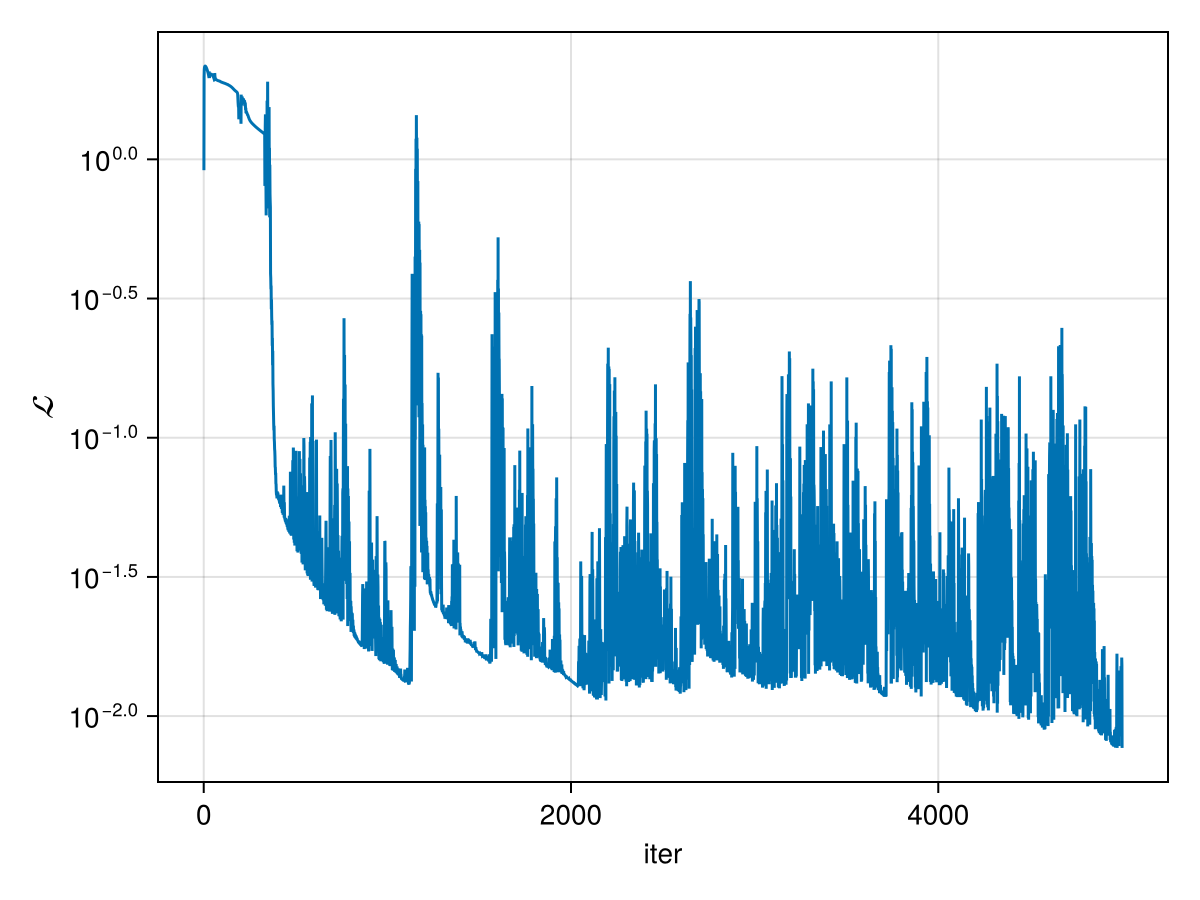

In [41]:
fig = CairoMakie.Figure()
ax = CairoMakie.Axis(fig[1, 1],yscale=log10,xlabel="iter",ylabel=L"\mathcal{L}")
CairoMakie.lines!(ax,loss_history_NODEs)
fig